In [22]:
import pandas as pd
df = pd.read_csv("titles.csv")
df.head()

,id,title,type,description,release_year,age_certification,runtime,genres,production_countries,seasons,imdb_id,imdb_score,imdb_votes,tmdb_popularity,tmdb_score
0,ts300399,Five Came Back: The Reference Films,SHOW,This collection includes 12 World War II-era p...,1945,TV-MA,51,['documentation'],['US'],1.0,NaN,NaN,NaN,0.600,NaN
1,tm84618,Taxi Driver,MOVIE,A mentally unstable Vietnam War veteran works ...,1976,R,114,"['drama', 'crime']",['US'],NaN,tt0075314,8.2,808582.0,40.965,8.179
2,tm154986,Deliverance,MOVIE,Intent on seeing the Cahulawassee River before...,1972,R,109,"['drama', 'action', 'thriller', 'european']",['US'],NaN,tt0068473,7.7,107673.0,10.010,7.300
3,tm127384,Monty Python and the Holy Grail,MOVIE,"King Arthur, accompanied by his squire, recrui...",1975,PG,91,"['fantasy', 'action', 'comedy']",['GB'],NaN,tt0071853,8.2,534486.0,15.461,7.811
4,tm120801,The Dirty Dozen,MOVIE,12 American military prisoners in World War II...,1967,NaN,150,"['war', 'action']","['GB', 'US']",NaN,tt0061578,7.7,72662.0,20.398,7.600


In [2]:
df.shape        # rows, columns
df.columns      # column names
df.info()       # data types

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5850 entries, 0 to 5849
Data columns (total 15 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    5850 non-null   object 
 1   title                 5849 non-null   object 
 2   type                  5850 non-null   object 
 3   description           5832 non-null   object 
 4   release_year          5850 non-null   int64  
 5   age_certification     3231 non-null   object 
 6   runtime               5850 non-null   int64  
 7   genres                5850 non-null   object 
 8   production_countries  5850 non-null   object 
 9   seasons               2106 non-null   float64
 10  imdb_id               5447 non-null   object 
 11  imdb_score            5368 non-null   float64
 12  imdb_votes            5352 non-null   float64
 13  tmdb_popularity       5759 non-null   float64
 14  tmdb_score            5539 non-null   float64
dtypes: float64(5), int64(

In [3]:
df.isnull().sum()

id                         0
title                      1
type                       0
description               18
release_year               0
age_certification       2619
runtime                    0
genres                     0
production_countries       0
seasons                 3744
imdb_id                  403
imdb_score               482
imdb_votes               498
tmdb_popularity           91
tmdb_score               311
dtype: int64

In [23]:
df = df.copy()
df[df.select_dtypes(include='object').columns] = df.select_dtypes(include='object').fillna("Unknown")
df[df.select_dtypes(include='number').columns] = df.select_dtypes(include='number').fillna(0)

In [6]:
df.isnull().sum()

id                      0
title                   0
type                    0
description             0
release_year            0
age_certification       0
runtime                 0
genres                  0
production_countries    0
seasons                 0
imdb_id                 0
imdb_score              0
imdb_votes              0
tmdb_popularity         0
tmdb_score              0
dtype: int64

In [7]:
df['type'].value_counts()

type
MOVIE    3744
SHOW     2106
Name: count, dtype: int64

In [8]:
df['production_countries'].value_counts().head(10)

production_countries
['US']    1959
['IN']     599
['JP']     264
[]         229
['KR']     222
['GB']     218
['ES']     161
['FR']     125
['CA']     107
['MX']      98
Name: count, dtype: int64

In [9]:
df['production_countries'].value_counts().head(10)

production_countries
['US']    1959
['IN']     599
['JP']     264
[]         229
['KR']     222
['GB']     218
['ES']     161
['FR']     125
['CA']     107
['MX']      98
Name: count, dtype: int64

In [10]:
df['genres'].value_counts().head(10)

genres
['comedy']                        484
['documentation']                 329
['drama']                         328
['comedy', 'drama']               135
['drama', 'romance']              124
['reality']                       113
['drama', 'comedy']               109
['comedy', 'documentation']       104
['comedy', 'romance']              69
['comedy', 'drama', 'romance']     67
Name: count, dtype: int64

In [11]:
df['imdb_score'].describe()

count        5850
unique         81
top       Unknown
freq          482
Name: imdb_score, dtype: object

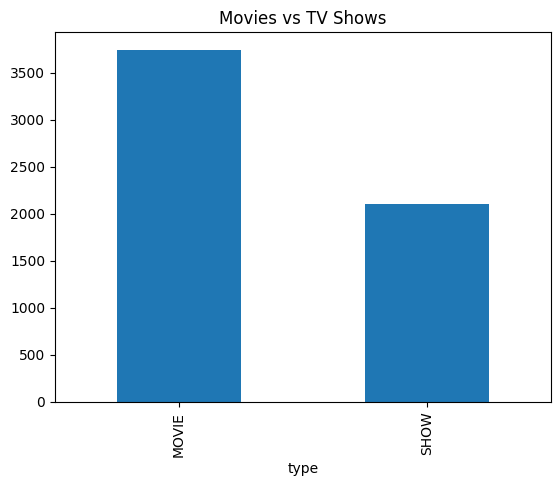

In [12]:
import matplotlib.pyplot as plt

df['type'].value_counts().plot(kind='bar')
plt.title("Movies vs TV Shows")
plt.show()

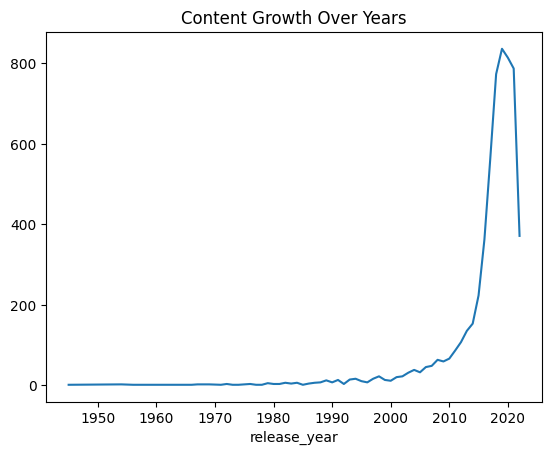

In [13]:
df['release_year'].value_counts().sort_index().plot()
plt.title("Content Growth Over Years")
plt.show()

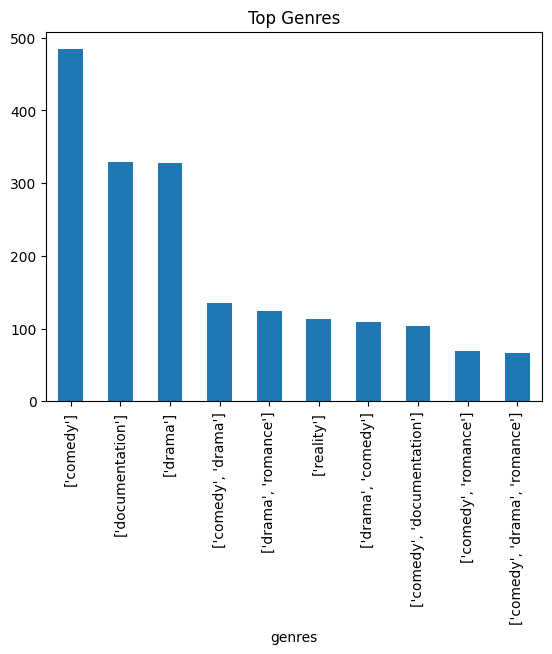

In [14]:
df['genres'].value_counts().head(10).plot(kind='bar')
plt.title("Top Genres")
plt.show()

In [17]:
# Top 10
df['imdb_score'] = pd.to_numeric(df['imdb_score'], errors='coerce')

In [18]:
df = df.dropna(subset=['imdb_score'])

In [25]:
df.sort_values(by='imdb_score', ascending=False).head(10)

,id,title,type,description,release_year,age_certification,runtime,genres,production_countries,seasons,imdb_id,imdb_score,imdb_votes,tmdb_popularity,tmdb_score
2658,ts265844,#ABtalks,SHOW,#ABtalks is a YouTube interview show hosted by...,2018,TV-PG,68,[],[],1.0,tt12635254,9.6,7.0,0.000,0.000
564,ts160526,Khawatir,SHOW,A TV show devoted to help young people to be m...,2005,TV-14,19,['reality'],[],11.0,tt3062514,9.5,3115.0,0.000,0.000
216,ts4,Breaking Bad,SHOW,"When Walter White, a New Mexico chemistry teac...",2008,TV-MA,48,"['drama', 'crime', 'thriller']",['US'],5.0,tt0903747,9.5,1775990.0,353.848,8.790
233,ts3371,Avatar: The Last Airbender,SHOW,"In a war-torn world of elemental magic, a youn...",2005,TV-Y7,24,"['scifi', 'animation', 'action', 'family', 'fa...",['US'],3.0,tt0417299,9.3,303666.0,56.915,8.700
3147,ts85398,Our Planet,SHOW,Experience our planet's natural beauty and exa...,2019,TV-G,50,['documentation'],['GB'],1.0,tt9253866,9.3,42259.0,19.942,8.800
1258,ts37660,Reply 1988,SHOW,A nostalgic trip back to the late 1980s throug...,2015,TV-14,92,"['comedy', 'drama', 'family', 'romance']",['KR'],1.0,tt5182866,9.2,6718.0,18.370,8.700
1092,tm250247,Chhota Bheem & Krishna vs Zimbara,MOVIE,Chhota Bheem Aur Krishna vs Zimbara is an Indi...,2013,G,64,['animation'],[],0.0,tt6417984,9.1,16.0,1.442,0.000
3500,ts90621,Kota Factory,SHOW,"Dedicated to Shrimati SL Loney ji, Shri Irodov...",2019,TV-MA,39,"['drama', 'comedy']",['IN'],2.0,tt9432978,9.1,69316.0,9.584,8.300
1886,ts78298,My Mister,SHOW,"In a world that is less than kind, a young wom...",2018,TV-14,70,"['drama', 'family']",['KR'],1.0,tt7923710,9.1,6043.0,13.025,8.900
4771,tm996762,Major,MOVIE,Based on the life of real-life Hero Major Sand...,2022,Unknown,149,"['action', 'drama']",['IN'],0.0,tt9851854,9.1,7576.0,6.429,8.188


In [20]:
pd.to_numeric(..., errors='coerce')

Ellipsis

In [21]:
df.sort_values(by='imdb_score').head(10)

,id,title,type,description,release_year,age_certification,runtime,genres,production_countries,seasons,imdb_id,imdb_score,imdb_votes,tmdb_popularity,tmdb_score
1633,tm549892,Aerials,MOVIE,Earth is invaded by Aliens from outer space. A...,2016,Unknown,90,"['thriller', 'drama', 'scifi']",['AE'],Unknown,tt5314138,1.5,388.0,1.81,Unknown
3623,tm839411,Me Against You: Mr. S's Vendetta,MOVIE,A young couple who makes popular YouTube video...,2020,Unknown,64,"['comedy', 'family', 'european']",['IT'],Unknown,tt11559652,1.6,370.0,8.374,8.2
1091,tm171891,Himmatwala,MOVIE,When a temple priest commits suicide after bei...,2013,Unknown,150,"['comedy', 'drama', 'action']",['IN'],Unknown,tt2344678,1.7,8648.0,0.6,3.3
1577,tm232930,Kyaa Kool Hain Hum 3,MOVIE,In order to impress his girlfriend's conservat...,2016,Unknown,124,['comedy'],['IN'],Unknown,tt5290620,1.9,4356.0,4.658,3.1
748,tm53395,FRED 3: Camp Fred,MOVIE,"Schools out, and Fred Figglehorn's dream of wa...",2012,PG,81,"['comedy', 'family']",['US'],Unknown,tt2395219,2.0,2654.0,5.926,5.6
5298,ts280693,Thomas & Friends: All Engines Go!,SHOW,"In a reboot of the classic TV series, a younge...",2021,TV-Y,11,"['animation', 'fantasy', 'drama', 'family', 'm...",['US'],1.0,tt13940396,2.0,555.0,1.287,8.0
5695,ts319303,He's Expecting,SHOW,When a successful ad executive who's got it al...,2022,TV-PG,26,"['drama', 'comedy', 'romance', 'fantasy']",['JP'],1.0,tt14719276,2.0,3019.0,11.314,4.0
1695,tm350727,Hajwala: The Missing Engine,MOVIE,Khalid and Kehailan are two team leaders who a...,2016,R,96,"['drama', 'action', 'crime', 'sport', 'thriller']",['AE'],Unknown,tt6200274,2.0,255.0,1.389,6.2
19,tm94651,Dostana,MOVIE,Two close friends decide to enter law enforcem...,1980,Unknown,161,"['drama', 'comedy', 'crime', 'romance', 'action']",['IN'],Unknown,tt0080653,2.1,25.0,3.98,4.9
5320,ts287149,Hype House,SHOW,"From humble beginnings to overnight fame, thes...",2022,TV-14,32,['reality'],['US'],1.0,tt15257704,2.1,2915.0,3.204,5.8


In [26]:
df.to_csv("cleaned_netflix_data.csv", index=False)